In [22]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import time
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

#prereq = "para trabajar pre req progv22025-09-15095342_procesado.xlsx"
#historial = "detalle matricula cohorte 2019.xlsx"
historial = "historia_todos.csv"

                                

In [23]:
def calcular_num_intentos(df: pd.DataFrame) -> pd.DataFrame:
    # Paso 1: quedarse con intentos únicos por periodo
    df_unique = df[['Pidm', 'Cod materia curso', 'Periodo']].drop_duplicates()

    # Paso 2: ordenar por periodo
    df_unique = df_unique.sort_values(['Pidm', 'Cod materia curso', 'Periodo'])

    # Paso 3: generar número de intento acumulado
    # rank(method='dense') da consecutivos (1,2,3..) por periodo distinto
    df_unique['num_intentos_asignatura'] = (
        df_unique.groupby(['Pidm', 'Cod materia curso']).cumcount() + 1
    )

    # Paso 4: hacer merge con el dataframe original
    df_result = df.merge(
        df_unique,
        on=['Pidm', 'Cod materia curso', 'Periodo'],
        how='left'
    )

    return df_result

In [24]:
## Funciones de limpieza del DataFrame

def arreglar_comas_por_puntos(df: pd.DataFrame, cols_excluir: list) -> pd.DataFrame:
    """
    Reemplaza comas (,) por puntos (.) en todas las columnas tipo string,
    excepto en las columnas listadas en cols_excluir.
    Intenta convertir los valores resultantes a float.
    """
    for col in df.columns:
        if col not in cols_excluir and df[col].dtype == object:
            df[col] = df[col].str.replace(",", ".", regex=False)
            # Intentar conversión a float cuando sea posible
            try:
                df[col] = df[col].astype(float)
            except ValueError:
                pass  # si no se puede convertir, se queda como string
            print(f"[Comas→Puntos] Procesada columna: {col}")
        elif col in cols_excluir:
            print(f"[Comas→Puntos] Columna excluida: {col}")
    return df


def imputar_valores(df: pd.DataFrame) -> pd.DataFrame:
    """Imputa valores en columnas específicas."""
    # Columna repitencia → vacíos a 0.0
    col_repitencia = "_ Matricula detalle para analisis.repitencia profesor referencia"
    if col_repitencia in df.columns:
        antes = df[col_repitencia].isna().sum()
        df[col_repitencia] = df[col_repitencia].fillna(0).astype(float)
        despues = df[col_repitencia].isna().sum()
        print(f"[Imputación] Columna '{col_repitencia}': {antes} vacíos reemplazados por 0.0")

    # Columna Procedencia Categoria → reemplazar "6 No registra" por NaN
    col_procedencia = "_ Matricula detalle para analisis.Procedencia Categoria"
    if col_procedencia in df.columns:
        conteo = (df[col_procedencia] == "6 No registra").sum()
        df[col_procedencia] = df[col_procedencia].replace("6 No registra", np.nan)
        print(f"[Imputación] Columna '{col_procedencia}': {conteo} valores '6 No registra' reemplazados por NaN")

    # Columna Sexo → reemplazar -99 por NaN
    col_sexo = "_ Matricula detalle para analisis.Sexo"
    if col_sexo in df.columns:
        conteo = (df[col_sexo] == -99).sum()
        df[col_sexo] = df[col_sexo].replace(-99, np.nan)
        print(f"[Imputación] Columna '{col_sexo}': {conteo} valores '-99' reemplazados por NaN")

    # Columna Calificacion_Final → vacíos a -1
    col_nota_final = "Calificacion_Final"
    if col_nota_final in df.columns:
        conteo = df[col_nota_final].isna().sum()
        df[col_nota_final] = df[col_nota_final].fillna(-1).astype(float)
        print(f"[Imputación] Columna '{col_nota_final}': {conteo} vacíos reemplazados por -1")

     # Añadir columna de numero de intentos asignatura
    df = calcular_num_intentos(df)
    print(f"[Imputación] Columna num_intentos_asignatura': usando funcion calcular_num_intentos")

    return df


def eliminar_columnas_vacias(df: pd.DataFrame, columnas_eliminadas: list) -> pd.DataFrame:
    """Elimina columnas 100% vacías."""
    cols_vacias = df.columns[df.isna().all()].tolist()
    if cols_vacias:
        df = df.drop(columns=cols_vacias)
        columnas_eliminadas.extend(cols_vacias)
        print(f"[Columnas] Eliminadas columnas vacías: {cols_vacias}")
    else:
        print("[Columnas] No se encontraron columnas totalmente vacías")
    return df


def eliminar_filas_por_columna(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """Elimina filas con nulos en columnas con <20% vacíos."""
    filas_eliminadas_total = 0
    total_filas_inicial = len(df)

    for col in df.columns:
        nulos = df[col].isna().sum()
        porcentaje = nulos / len(df) if len(df) > 0 else 0

        if porcentaje == 0:
            continue

        if porcentaje < 0.20:
            filas_antes = len(df)
            df = df.dropna(subset=[col])
            filas_despues = len(df)
            eliminadas = filas_antes - filas_despues
            filas_eliminadas_total += eliminadas
            print(f"[Filas] Columna '{col}': {porcentaje:.2%} nulos → eliminadas {eliminadas} filas")
        else:
            print(f"[Aviso] Columna '{col}' tiene {porcentaje:.2%} de valores nulos (≥20%), no se eliminaron filas")

    filas_finales = len(df)
    print(f"[Filas] Total eliminadas: {filas_eliminadas_total} (de {total_filas_inicial} → {filas_finales})")

    return df, filas_eliminadas_total

def eliminar_filas_por_columna_ignorando_col_prereq(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """
    Elimina filas con nulos en columnas con <20% vacíos,
    ignorando las columnas que siguen el patrón Prereq_i_[Atributo].
    """
    filas_eliminadas_total = 0
    total_filas_inicial = len(df)

    for col in df.columns:
        # Ignorar columnas de prerequisitos
        if col.startswith("Prereq_"):
            print(f"[Ignorado] Columna '{col}' pertenece a prerequisitos, no se revisa.")
            continue

        nulos = df[col].isna().sum()
        porcentaje = nulos / len(df) if len(df) > 0 else 0

        if porcentaje == 0:
            continue

        if porcentaje < 0.20:
            filas_antes = len(df)
            df = df.dropna(subset=[col])
            filas_despues = len(df)
            eliminadas = filas_antes - filas_despues
            filas_eliminadas_total += eliminadas
            print(f"[Filas] Columna '{col}': {porcentaje:.2%} nulos → eliminadas {eliminadas} filas")
        else:
            print(f"[Aviso] Columna '{col}' tiene {porcentaje:.2%} de valores nulos (≥20%), no se eliminaron filas")

    filas_finales = len(df)
    print(f"[Filas] Total eliminadas: {filas_eliminadas_total} (de {total_filas_inicial} → {filas_finales})")

    return df, filas_eliminadas_total



def limpiar_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Función principal que limpia el dataframe según reglas definidas."""
    print("=== Iniciando limpieza del DataFrame ===")

    # Imputación de valores
    df = imputar_valores(df)

    # Eliminar columnas vacías
    columnas_eliminadas = []
    df = eliminar_columnas_vacias(df, columnas_eliminadas)

    # Eliminar filas según condición por columnas
    #df, filas_eliminadas = eliminar_filas_por_columna(df)
    df, filas_eliminadas = eliminar_filas_por_columna_ignorando_col_prereq(df)
    
    # Resumen final
    print("\n=== Resumen limpieza ===")
    print(f"Filas eliminadas: {filas_eliminadas}")
    print(f"Columnas eliminadas: {columnas_eliminadas}")

    return df


In [25]:
#Renombrar Columnas

def renombrar_columnas(df: pd.DataFrame):
    """
    Renombra columnas largas por versiones cortas en snake_case.
    Devuelve:
      - DataFrame con columnas renombradas
      - Lista con columnas finales de análisis (col_usar renombradas)
      - String con el nombre de la variable objetivo renombrada
    """

    # Mapeo de nombres originales a nuevos
    mapping = {
        "_ Matricula detalle para analisis.repitencia profesor referencia": "repitencia_prof_ref",
        "Nombre_Programa": "programa",
        "_ Matricula detalle para analisis.Prof_Codigo": "profesor_codigo",
        "_ Matricula detalle para analisis.pga inicial": "pga_inicial",
        "_ Matricula detalle para analisis.prom semestral t_1": "promedio_sem_t1",
        "_ Matricula detalle para analisis.Sexo": "sexo",
        "_ Matricula detalle para analisis.Asistencia CREE t_1": "asistencia_cree_t1",
        "_ Matricula detalle para analisis.Procedencia Categoria": "procedencia_categoria",
        "_ Matricula detalle para analisis.Edad cursan asignatura": "edad_curso",
        "_ Matricula detalle para analisis.Calif Final _ Retiros": "resultado_final"
    }

    # Renombrar columnas
    df = df.rename(columns=mapping)

    # Construir lista final de columnas de análisis
    col_usar = [
        "repitencia_prof_ref",
        "programa",
        "profesor_codigo",
        "pga_inicial",
        "promedio_sem_t1",
        "sexo",
        "asistencia_cree_t1",
        "procedencia_categoria",
        "edad_curso",
        "num_intentos_asignatura"
    ]

    # Variable objetivo
    var_objetivo = "resultado_final"

    return df, col_usar, var_objetivo


In [26]:
## Indentificar columnas de prerequisitos válidas

def columnas_prereq_validas(df: pd.DataFrame, umbral: float = 0.8) -> list:
    """
    Identifica las columnas de prerequisitos (Nota e Intentos) que cumplen con tener
    al menos un 80% de valores no nulos en la columna Nota.
    
    Parámetros:
        df: DataFrame de entrada
        umbral: proporción mínima de valores no nulos (default=0.8)
    
    Retorna:
        lista con las columnas Prereq_i_Nota y Prereq_i_Intentos que cumplen el criterio.
    """
    columnas_seleccionadas = []
    prereq_notas = [c for c in df.columns if c.startswith("Prereq_") and c.endswith("_Nota")]

    for col_nota in prereq_notas:
        col_intentos = col_nota.replace("_Nota", "_Intentos")

        if col_intentos not in df.columns:
            print(f"[Aviso] No se encontró la columna de intentos para {col_nota}, se omite el par.")
            continue

        total = len(df)
        no_nulos = df[col_nota].notna().sum()
        proporcion = no_nulos / total if total > 0 else 0

        if proporcion >= umbral:
            columnas_seleccionadas.extend([col_nota, col_intentos])
            print(f"[Incluido] {col_nota} y {col_intentos} → {proporcion:.2%} valores válidos")
        else:
            print(f"[Excluido] {col_nota} y {col_intentos} → {proporcion:.2%} valores válidos (<{umbral:.0%})")

    print("\nResumen final:")
    print(f"Columnas seleccionadas: {columnas_seleccionadas}")

    return columnas_seleccionadas


In [27]:
#Cambiar a category

def cambiar_a_category(df, cols):
    # Convierte columnas a category si existen

    for c in cols:
        if c in df.columns:
            df[c] = df[c].astype("category")
        else:
            print(f"Columna no encontrada: {c}")

    # Verificar tipos resultantes
    print(df[ [c for c in cols if c in df.columns] ].dtypes)  

    return df


    

In [28]:
# Crear scorer personalizado

from sklearn.metrics import make_scorer
import numpy as np

def recall_margen(y_true, y_pred, margen=0.05):
    """
    Calcula recall con un margen de error tolerado.
    """
    # Convertir a arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Predicción correcta = dentro del margen
    aciertos = np.abs(y_true - y_pred) <= margen

    # En este contexto, todo y_true es un "positivo real"
    TP = np.sum(aciertos)            # aciertos
    FN = np.sum(~aciertos)           # fallos

    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    return recall


In [29]:
# Tuning de hiperparámetros

from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

def tuning_hiperparametros_grid(model,x_train, y_train, cv=5):

    param_grid = {
        "max_depth": [3, 5, 7, 10],
        "learning_rate": [0.05, 0.1, 0.2],
        "n_estimators": [ 500, 800],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [ 3, 5, 7],
        "gamma": [0, 0.1, 0.3, 0.5],
        "reg_alpha": [ 0.1, 1],
        "reg_lambda": [ 2, 3]
    }

    # Crear scorer compatible con sklearn
    recall_scorer = make_scorer(recall_margen, greater_is_better=True)

    # Configurar búsqueda con validación cruzada de 5 folds
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        #scoring="neg_root_mean_squared_error", # queremos optimizar RMSE
        scoring=recall_scorer,
        cv=cv,
        verbose=2,
        n_jobs=-1
    )

    # Ejecutar búsqueda
    grid_search.fit(x_train, y_train)

     # Resultados
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_score = -grid_search.best_score_  # volver a RMSE positivo

    print("Mejores parámetros encontrados:", grid_search.best_params_)
    print("Mejor score (RMSE):", -grid_search.best_score_)

    return best_model, best_params, best_score



from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error 

def optimizar_xgboost_random(modelo, X_train, y_train, n_iter=50, cv=7, random_state=42):
    """
    Optimiza un modelo XGBoost con RandomizedSearchCV para minimizar RMSE.

    Parámetros:
        modelo: instancia de XGBRegressor (sin entrenar).
        X_train (pd.DataFrame o np.array): variables de entrenamiento.
        y_train (pd.Series o np.array): variable objetivo.
        n_iter (int): número de combinaciones aleatorias a probar.
        cv (int): número de folds para validación cruzada.
        random_state (int): semilla de aleatoriedad.

    Retorna:
        best_model: modelo entrenado con los mejores hiperparámetros.
        best_params: diccionario con mejores parámetros.
        best_score: mejor score en validación cruzada (RMSE).
    """

    # Definir espacio de búsqueda
    param_dist = {
        "max_depth": [3, 5, 7, 10],
        "learning_rate": [0.05, 0.1, 0.2],
        "n_estimators": [ 500, 800],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [ 3, 5, 7],
        "gamma": [0, 0.1, 0.3, 0.5],
        "reg_alpha": [ 0.1, 1],
        "reg_lambda": [ 2, 3]
    }

    # Definir scorer para RMSE (negativo porque sklearn maximiza por defecto)
    rmse_scorer = make_scorer(lambda y_true, y_pred: -np.sqrt(mean_squared_error(y_true, y_pred)))

    # Crear scorer compatible con sklearn
    recall_scorer = make_scorer(recall_margen, greater_is_better=True)


    # Configurar búsqueda
    random_search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=param_dist,
        n_iter=n_iter,
        #scoring=rmse_scorer,
        scoring=recall_scorer,
        cv=cv,
        verbose=2,
        random_state=random_state,
        n_jobs=-1
    )

    # Ejecutar búsqueda
    random_search.fit(X_train, y_train)

    # Resultados
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    best_score = -random_search.best_score_  # volver a RMSE positivo

    print("Mejores parámetros encontrados:", best_params)
    print("Mejor score (RMSE):", best_score)

    return best_model, best_params, best_score


In [30]:
# Entrenar_xgboost_regresion

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Aquí asumimos que ya tienes la función optimizar_xgboost_random definida previamente


def entrenar_xgboost_regresion(df, columna_objetivo, columnas_predictores, tuning=True):
    """
    Entrena un modelo XGBoost de regresión sobre un dataframe y (opcionalmente) 
    ajusta hiperparámetros con RandomizedSearchCV.

    Parámetros:
        df (pd.DataFrame): DataFrame con los datos
        columna_objetivo (str): Nombre de la columna a predecir
        columnas_predictores (list): Lista con nombres de columnas de entrada
        tuning (bool): Si True, aplica optimización con RandomizedSearchCV

    Retorna:
        modelo (XGBRegressor): Modelo entrenado (mejorado si tuning=True)
        df_resultados (pd.DataFrame): DataFrame original con columna de predicciones
        metricas (dict): RMSE, MAE, R2
        X_train, X_test, y_train, y_test
    """

    # Separar variables
    X = df[columnas_predictores]
    y = df[columna_objetivo]

    # Dividir en train (80%) y test (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Definir modelo base
    modelo = XGBRegressor(
        objective="reg:squarederror",
        #objective="reg:absoluteerror",
        enable_categorical=True,
        random_state=42
    )

    # --- Ajuste de hiperparámetros ---
    if tuning:
        print("\n🔎 Iniciando optimización de hiperparámetros con GridSearchCV...\n")
        #modelo, best_params, best_score = optimizar_xgboost_random(
        #    modelo, X_train, y_train, n_iter=150, cv=7
        #)
        modelo, best_params, best_score = tuning_hiperparametros_grid(
            modelo, X_train, y_train, cv=5)
        print("\n✅ Optimización finalizada.")
        print("Mejores parámetros aplicados al modelo:", best_params)
        print("Mejor score validación cruzada (RMSE):", best_score)

    # Entrenar con mejores parámetros
    modelo.fit(X_train, y_train)

    # Predicciones en test
    y_pred = modelo.predict(X_test)

    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metricas = {"RMSE": rmse, "MAE": mae, "R2": r2}

    # Mostrar métricas como tabla
    print("\n📊 Métricas de evaluación del modelo en test:\n")
    print(pd.DataFrame(metricas, index=["Valores"]).T)

    # Agregar columna de predicciones al df completo
    df_resultados = df.copy()
    df_resultados["Prediccion_XGB"] = modelo.predict(X)

    return modelo, df_resultados, metricas, X_train, X_test, y_train, y_test



In [31]:
# mostrar_arbol & mostrar_importancia_gain & reporte_importancia

from xgboost import plot_tree
import matplotlib.pyplot as plt
from xgboost import plot_importance

def mostrar_arbol(modelo, num_tree=0, ancho=40, alto=20, orientacion="LR"):
    """
    Muestra el árbol de decisión generado por XGBoost.

    Parámetros:
        modelo (XGBRegressor): Modelo entrenado
        num_tree (int): Índice del árbol a graficar
        ancho (int): Ancho de la figura
        alto (int): Alto de la figura
        orientacion (str): Dirección del árbol ("LR"=izq-der, "TB"=arriba-abajo)
    """
    plt.figure(figsize=(ancho, alto))
    plot_tree(modelo, num_trees=num_tree, rankdir=orientacion)
    plt.show()


def mostrar_importancia_gain(modelo, top_n=20):
    """
    Muestra la importancia de las variables en el modelo.
    
    Parámetros:
        modelo (XGBRegressor): Modelo entrenado
        top_n (int): Número de variables a mostrar
    """
    plt.figure(figsize=(10,6))
    plot_importance(modelo, importance_type="gain", max_num_features=top_n, height=0.5)
    plt.title("Importancia de variables (gain)")
    plt.show()


def reporte_importancia(modelo):
    """
    Genera un reporte tabulado de importancia de variables
    con métricas: gain, weight y cover.
    """
    booster = modelo.get_booster()

    # Obtener cada métrica como diccionario
    importancia_gain = booster.get_score(importance_type="gain")
    importancia_weight = booster.get_score(importance_type="weight")
    importancia_cover = booster.get_score(importance_type="cover")

    # Convertir a DataFrame
    df_gain = pd.DataFrame.from_dict(importancia_gain, orient="index", columns=["Gain"])
    df_weight = pd.DataFrame.from_dict(importancia_weight, orient="index", columns=["Weight"])
    df_cover = pd.DataFrame.from_dict(importancia_cover, orient="index", columns=["Cover"])

    # Unir todo
    df_importancia = df_gain.join(df_weight).join(df_cover)

    # Ordenar por Gain
    df_importancia = df_importancia.sort_values("Gain", ascending=False)

    print("\n📊 Reporte de Importancia de Variables (XGBoost)\n")
    print(df_importancia)

    return df_importancia


In [32]:
#matriz_confusion

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def matriz_confusion_personalizada(df, columna_objetivo, columna_prediccion, margen_error=0.2, graficar=True):
    """
    Construye una matriz de confusión personalizada basada en un margen de error.

    Parámetros:
        df (pd.DataFrame): DataFrame con columna real y predicción
        columna_objetivo (str): Nombre de la columna real
        columna_prediccion (str): Nombre de la columna de predicciones
        margen_error (float): Margen permitido para considerar la predicción correcta
        graficar (bool): Si True, muestra la matriz de confusión en gráfico

    Retorna:
        matriz (np.ndarray): Matriz de confusión
        df_resultados (pd.DataFrame): DataFrame con columna de éxito (1 o 0)
    """

    # Copiar para no alterar el original
    df_resultados = df.copy()

    # Redondear predicciones a 2 decimales
    df_resultados[columna_prediccion] = df_resultados[columna_prediccion].round(2)

    # Convertir cualquier valor < 0 en -1
    df_resultados[columna_prediccion] = df_resultados[columna_prediccion].apply(lambda x: -1 if x < 0 else x)

    # Crear etiqueta de éxito: 1 si la diferencia es <= margen_error
    df_resultados["Exito"] = np.where(
        abs(df_resultados[columna_objetivo] - df_resultados[columna_prediccion]) <= margen_error, 
        1, 
        0
    )

    # Etiqueta real: siempre 1 (correcto) porque evaluamos predicciones
    # Aquí podemos definir "ground truth" como si el valor real fuera siempre válido
    # entonces comparamos con éxito/fallo de predicción
    y_true = np.ones(len(df_resultados))   # todos deberían ser "correctos"
    y_pred = df_resultados["Exito"]

    # Calcular matriz de confusión
    matriz = confusion_matrix(y_true, y_pred, labels=[1,0])
    print(classification_report(y_true, y_pred))

    if graficar:
        disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["Éxito", "Fallo"])
        disp.plot(cmap="Blues")
        plt.title("Matriz de Confusión Personalizada")
        plt.show()

    return matriz, df_resultados


In [33]:
#shap

import shap 

def interpretar_xgboost_shap(modelo, X, columnas_predictores, top_n=5, id_check=0):
    """
    Genera interpretaciones SHAP para un modelo XGBoost:
    - Summary plot (impacto global de las variables)
    - Dependence plots para las N variables más importantes

    Parámetros:
        modelo: XGBRegressor ya entrenado
        X (pd.DataFrame): datos (X_train o X_test)
        columnas_predictores (list): lista con nombres de variables
        top_n (int): número de variables más importantes a mostrar en dependence plots
    """
    # Crear explicador SHAP
    explainer = shap.TreeExplainer(modelo)

    # Calcular valores SHAP
    shap_values = explainer(X)

    # --- 1. Summary plot ---
    print("📊 Generando summary plot global...")
    shap.summary_plot(shap_values, X, feature_names=columnas_predictores)

    # --- 2. Dependence plots ---
    print(f"\n📊 Generando dependence plots para las {top_n} variables más importantes...\n")
    
    # Obtener importancia (gain) desde XGBoost
    importancia_gain = modelo.get_booster().get_score(importance_type="gain")
    importancia_df = pd.DataFrame.from_dict(importancia_gain, orient="index", columns=["Gain"])
    importancia_df = importancia_df.sort_values("Gain", ascending=False).head(top_n)

    for feature in importancia_df.index:
        print(f"➡️ Dependence plot para variable: {feature}")
        shap.dependence_plot(feature, shap_values.values, X, feature_names=columnas_predictores)

    i = id_check  # índice del estudiante en X_test
    print(f"📌 Explicación de la predicción para el estudiante {i}")
    shap.plots.waterfall(shap_values[i]) 

def gen_xboost_waterfall_plot(modelo, X, id_check=0):
    
    # Crear explicador SHAP
    explainer = shap.TreeExplainer(modelo)

    # Calcular valores SHAP
    shap_values = explainer(X)

    i = id_check  # índice del estudiante en X_test
    print(f"📌 Explicación de la predicción para el estudiante {i}")
    shap.plots.waterfall(shap_values[i])       


In [34]:
#Guardar resultados

def guardar_resultados(df):
        """Guarda los resultados en un archivo Excel"""
        if df is None:
            print("No hay resultados para guardar")
            return

        timestamp = pd.Timestamp.now().strftime("%Y-%m-%d%H%M%S")
        #nombre_archivo = "Resultados v6/resultados_prerrequisitos_v6_cadenas_"+timestamp+".xlsx"
        nombre_archivo = "Resultados v6/resultados_prerrequisitos_v6_cadenas_"+timestamp+".csv"

        try:
            # Limpiar columnas completamente vacías
            df = df.dropna(axis=1, how='all')
            print(f"✓ Guardando resultados en: {nombre_archivo} ...")
            #df.to_excel(nombre_archivo, index=False)
            df.to_csv(nombre_archivo, index=False)
            print(f"✓ Resultados guardados en: {nombre_archivo}")
            print(f"Columnas en el archivo: {len(df.columns)}")
        except Exception as e:
            print(f"Error al guardar resultados: {e}")

In [35]:
# CARGAR ARCHIVO
print("=== Reivsar asignaturas de prueba ===\n")


# Solicitar archivo de historial
while True:
    try:
        ruta_historial = historial#input("Ingrese la ruta del archivo 'historial_asignaturas.xlsx': ").strip()
        df_historial = pd.read_csv(ruta_historial, sep=';')
        print(f"✓ Archivo de historial cargado: {len(df_historial)} registros")
        break
    except Exception as e:
        print(f"Error al cargar historial: {e}")
        print("Intente nuevamente.\n")






=== Reivsar asignaturas de prueba ===

✓ Archivo de historial cargado: 517640 registros


In [36]:
#Limpiar DataFrame

cols_to_excl =[
        "Nombre_Programa",
        "_ Matricula detalle para analisis.Prof_Codigo",
        "_ Matricula detalle para analisis.Sexo",
        "_ Matricula detalle para analisis.Procedencia Categoria",
    ]

#["FIS1023","MAT1111","FIS1033"]#
asig_a_usar=["FIS1023"]#["FIS1023","MAT1111","EST7042","IST2089","MAT4011","IBA4032","MAT4258","MAT4260","FIS1033","FIS1043"]

df_usar = df_historial[
    #(df_historial["Observacion_Prerrequisito"] == "Prerrequisito cumplido") &
    (df_historial["Cod materia curso"].isin(asig_a_usar))
].copy()
df_usar=arreglar_comas_por_puntos(df_usar,cols_to_excl)
df_usar=limpiar_dataframe(df_usar)

[Comas→Puntos] Procesada columna: Nombre_Division
[Comas→Puntos] Procesada columna: Cod materia curso
[Comas→Puntos] Procesada columna: Materia_Aprobada
[Comas→Puntos] Procesada columna: Calificacion_Final
[Comas→Puntos] Procesada columna: Estado asignatura
[Comas→Puntos] Procesada columna: Descripcion_Materia
[Comas→Puntos] Procesada columna: DPTO Asignatura
[Comas→Puntos] Columna excluida: Nombre_Programa
[Comas→Puntos] Procesada columna: Codigo_Programa
[Comas→Puntos] Procesada columna: Observacion_Prerrequisito
[Comas→Puntos] Procesada columna: Prereq_1_Codigo
[Comas→Puntos] Procesada columna: Prereq_1_Nota
[Comas→Puntos] Procesada columna: Prereq_1_Tipo
[Comas→Puntos] Procesada columna: Prereq_1_EsCadena
[Comas→Puntos] Procesada columna: Prereq_2_Codigo
[Comas→Puntos] Procesada columna: Prereq_2_Nota
[Comas→Puntos] Procesada columna: Prereq_2_Tipo
[Comas→Puntos] Procesada columna: Prereq_2_EsCadena
[Comas→Puntos] Procesada columna: Prereq_3_Codigo
[Comas→Puntos] Procesada columna:


 == Resultados para programa:  FIS1023 - FÍSICA MECANICA == 

[Incluido] Prereq_1_Nota y Prereq_1_Intentos → 92.72% valores válidos

Resumen final:
Columnas seleccionadas: ['Prereq_1_Nota', 'Prereq_1_Intentos']
Columnas a usar (12): ['repitencia_prof_ref', 'programa', 'profesor_codigo', 'pga_inicial', 'promedio_sem_t1', 'sexo', 'asistencia_cree_t1', 'procedencia_categoria', 'edad_curso', 'num_intentos_asignatura', 'Prereq_1_Nota', 'Prereq_1_Intentos'] 
  Numero de filas a tener en cuenta: 4151
programa                 category
sexo                     category
procedencia_categoria    category
profesor_codigo          category
dtype: object

📊 Métricas de evaluación del modelo en test:

       Valores
RMSE  1.277116
MAE   0.818337
R2    0.196368
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.75      0.86      4151

    accuracy                           0.75      4151
   macro avg       0.50  

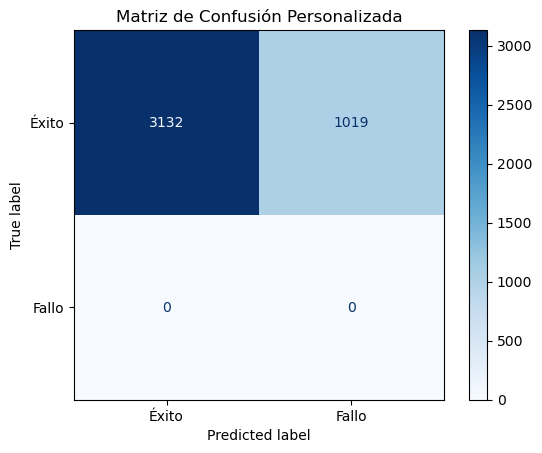

In [37]:
col_usar=[]
var_objetivo=""

for asig in asig_a_usar:
    nombre_asig = df_usar[df_usar["Cod materia curso"] == asig]["Descripcion_Materia"].iloc[0]
    print(f"\n == Resultados para programa:  {(asig)} - {(nombre_asig)} == \n")
    df_usar_filtrado = df_usar[df_usar["Cod materia curso"] == asig].copy()

    #La variable objetivo esta definida dentro de la función renombrar_columnas
    df_usar_filtrado,col_usar,var_objetivo=renombrar_columnas(df_usar_filtrado)

    lista_prereq_usar= columnas_prereq_validas(df_usar_filtrado, 0.8)

    col_usar = col_usar + lista_prereq_usar

    print(f"Columnas a usar ({len(col_usar)}): {col_usar} \n  Numero de filas a tener en cuenta: {len(df_usar_filtrado)}")

    #print(df_usar_filtrado.columns.values.tolist())

    cols_to_category = [
        "programa",
        "sexo",
        "procedencia_categoria",
        "profesor_codigo"
    ]


    df_usar_filtrado=cambiar_a_category(df_usar_filtrado, cols_to_category)



    modelo, df_pred, metricas, X_train, X_test, y_train, y_test = entrenar_xgboost_regresion(
        df=df_usar_filtrado,
        columna_objetivo=var_objetivo,
        columnas_predictores=col_usar
        ,tuning=False
    )

    col_prediccion="Prediccion_XGB"

    matriz_conf, df_pred= matriz_confusion_personalizada(df_pred, var_objetivo, col_prediccion, margen_error=0.3, graficar=True)
    #mostrar_importancia_gain(modelo, top_n=20)
    #interpretar_xgboost_shap(modelo, X_test, col_usar, top_n=1, id_check=0)

    #tuning_hiperparametros_grid(modelo, X_train, y_train)
    #best_model, best_params, best_score = optimizar_xgboost_random(modelo, X_train, y_train, n_iter=10, cv=3, random_state=42) 
    


In [39]:
# Comparación de modelos: RF vs XGB vs CatBoost
# ============================================

from __future__ import annotations
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import Dict, Any, List, Tuple, Optional

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    make_scorer
)
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import OrdinalEncoder

def preparar_datos(X: pd.DataFrame, modelo: str) -> np.ndarray:
    """
    Prepara X según el modelo:
    - RandomForest: ordinal encode de strings
    - XGBoost: convierte a category y usa enable_categorical
    - CatBoost: deja los strings tal cual
    """
    X_copy = X.copy()
    
    if modelo == "RandomForest":
        # Encode all columns as numeric (floats)
        for col in X_copy.columns:
            if X_copy[col].dtype.name == "category" or X_copy[col].dtype == object:
                X_copy[col] = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit_transform(X_copy[[col]]).astype(float)
            else:
                X_copy[col] = X_copy[col].astype(float)
        return X_copy.values

    elif modelo == "XGBoost":
        for col in X_copy.select_dtypes(include=["object"]).columns:
            X_copy[col] = X_copy[col].astype("category")
        return X_copy  # se pasa DataFrame con dtype category

    elif modelo == "CatBoost":
        return X_copy  # acepta strings directamente

    return X_copy


# XGBoost
from xgboost import XGBRegressor

# CatBoost (puede no estar instalado)
try:
    from catboost import CatBoostRegressor
    _HAS_CATBOOST = True
except Exception:
    _HAS_CATBOOST = False


# ------------------------------
# 1) Métrica personalizada
# ------------------------------
def recall_margen(y_true: np.ndarray, y_pred: np.ndarray, margin: float = 0.3) -> float:
    """
    'Recall' para regresión: porcentaje de casos donde |y_pred - y_true| <= margin.
    Equivale a tasa de aciertos dentro del margen.
    """
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    hits = np.abs(y_pred - y_true) <= margin
    return float(np.mean(hits))


def build_scorers(margin: float = 0.3) -> Dict[str, Any]:
    """
    Devuelve scorers para cross_val_score.
    - recall_scorer: nuestro recall dentro del margen (mayor es mejor).
    - rmse_scorer:   usar métrica negativa de sklearn (se invierte el signo).
    - mae_scorer, r2_scorer.
    """
    recall_scorer = make_scorer(recall_margen, greater_is_better=True, margin=margin)
    # En sklearn, RMSE se usa como 'neg_root_mean_squared_error'
    rmse_scorer = "neg_root_mean_squared_error"
    mae_scorer = "neg_mean_absolute_error"
    r2_scorer = "r2"
    return {
        "recall": recall_scorer,
        "rmse": rmse_scorer,
        "mae": mae_scorer,
        "r2": r2_scorer
    }


# ------------------------------
# 2) Split de datos
# ------------------------------
def split_data(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    test_size: float = 0.2,
    random_state: int = 42
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        X = df[feature_cols]            # <- DataFrame, NO .values
        y = df[target_col]              # <- Series
        return train_test_split(X, y, test_size=test_size, random_state=random_state)


# ------------------------------
# 3) Model factories (baselines)
# ------------------------------
def make_random_forest(params: Optional[Dict[str, Any]] = None) -> RandomForestRegressor:
    default = dict(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=42
    )
    if params:
        default.update(params)
    return RandomForestRegressor(**default)


def make_xgboost(params: Optional[Dict[str, Any]] = None) -> XGBRegressor:
    default = dict(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        tree_method="hist", # rápido y estable
        enable_categorical=True   
    )
    if params:
        default.update(params)
    return XGBRegressor(**default)


def make_catboost(params: Optional[Dict[str, Any]] = None, category_columns=[]) -> Optional[CatBoostRegressor]:
    if not _HAS_CATBOOST:
        return None
    default = dict(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        cat_features=category_columns
    )
    if params:
        default.update(params)
    return CatBoostRegressor(**default)


# ------------------------------
# 4) Entrenamiento + evaluación
# ------------------------------
@dataclass
class EvalResult:
    model_name: str
    test_rmse: float
    test_mae: float
    test_r2: float
    test_recall_margin: float
    cv_recall_mean: float
    cv_recall_std: float
    cv_rmse_mean: float
    cv_mae_mean: float
    cv_r2_mean: float


def evaluate_model(
    model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    margin: float = 0.3,
    n_splits: int = 5,
    random_state: int = 42
) -> EvalResult:
    # Fit
    model.fit(X_train, y_train)

    # Predicción en test
    y_pred = model.predict(X_test)

    # Métricas test
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)
    test_rec = recall_margen(y_test, y_pred, margin=margin)

    # Cross-validation
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scorers = build_scorers(margin)

    # Nota: las métricas negativas se invierten luego para que queden positivas
    cv_recall = cross_val_score(model, X_train, y_train, cv=cv, scoring=scorers["recall"])
    cv_rmse = -cross_val_score(model, X_train, y_train, cv=cv, scoring=scorers["rmse"])
    cv_mae  = -cross_val_score(model, X_train, y_train, cv=cv, scoring=scorers["mae"])
    cv_r2   =  cross_val_score(model, X_train, y_train, cv=cv, scoring=scorers["r2"])

    name = type(model).__name__
    return EvalResult(
        model_name=name,
        test_rmse=float(test_rmse),
        test_mae=float(test_mae),
        test_r2=float(test_r2),
        test_recall_margin=float(test_rec),
        cv_recall_mean=float(cv_recall.mean()),
        cv_recall_std=float(cv_recall.std()),
        cv_rmse_mean=float(cv_rmse.mean()),
        cv_mae_mean=float(cv_mae.mean()),
        cv_r2_mean=float(cv_r2.mean())
    )


# ------------------------------
# 5) Orquestador: corre y compara
# ------------------------------
def comparar_modelos(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    *,
    margin: float = 0.3,
    n_splits: int = 5,
    random_state: int = 42,
    rf_params: Optional[Dict[str, Any]] = None,
    xgb_params: Optional[Dict[str, Any]] = None,
    cat_params: Optional[Dict[str, Any]] = None,
    category_columns
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    - Divide 80/20
    - Entrena RF, XGB y (si está instalado) CatBoost
    - Evalúa en test + CV (incluyendo recall con margen)
    - Retorna tabla comparativa y dict con modelos entrenados
    """
    X_train, X_test, y_train, y_test = split_data(
        df, feature_cols, target_col, test_size=0.2, random_state=random_state
    )

    modelos = {}
    resultados: List[EvalResult] = []

    df_resultados = df.copy()
    X= df[feature_cols]
    X_rf = preparar_datos(X, "RandomForest")
    X_xg= preparar_datos(X, "XGBoost")
    X_cat= preparar_datos(X, "CatBoost")

    # Para cada modelo:
    X_train_rf = preparar_datos(X_train, "RandomForest")
    X_test_rf  = preparar_datos(X_test, "RandomForest")
   

    X_train_xgb = preparar_datos(X_train, "XGBoost")
    X_test_xgb  = preparar_datos(X_test, "XGBoost")

    X_train_cat = preparar_datos(X_train, "CatBoost")
    X_test_cat  = preparar_datos(X_test, "CatBoost")

    # Random Forest
    print("\n🔎 Iniciando RandomForest...\n")
    rf = make_random_forest(rf_params)
    res_rf = evaluate_model(rf, X_train_rf, y_train, X_test_rf, y_test,
                            margin=margin, n_splits=n_splits, random_state=random_state)
    modelos["RandomForest"] = rf
    resultados.append(res_rf)
    col_prediccion="Prediccion_RandomForest"
    df_resultados[col_prediccion] = rf.predict(X_rf)
    matriz_conf, df_pred= matriz_confusion_personalizada(df_resultados, target_col, col_prediccion, margen_error=0.3, graficar=True)

    # XGBoost
    print("\n🔎 Iniciando XGBOOST...\n")
    xgb = make_xgboost(xgb_params)
    res_xgb = evaluate_model(xgb, X_train_xgb, y_train, X_test_xgb, y_test,
                             margin=margin, n_splits=n_splits, random_state=random_state)
    modelos["XGBoost"] = xgb
    resultados.append(res_xgb)
    col_prediccion="Prediccion_XGBOOST"
    df_resultados[col_prediccion] = xgb.predict(X_xg)
    matriz_conf, df_pred= matriz_confusion_personalizada(df_resultados, target_col, col_prediccion, margen_error=0.3, graficar=True)

    # CatBoost (si está disponible)
    print("\n🔎 Iniciando CatBoost...\n")
    if _HAS_CATBOOST:
        cat = make_catboost(cat_params,category_columns)
        res_cat = evaluate_model(cat, X_train_cat, y_train, X_test_cat, y_test,
                                 margin=margin, n_splits=n_splits, random_state=random_state)
        modelos["CatBoost"] = cat
        resultados.append(res_cat)
        col_prediccion="Prediccion_CatBOOST"
        df_resultados[col_prediccion] = cat.predict(X_cat)
        matriz_conf, df_pred= matriz_confusion_personalizada(df_resultados, target_col, col_prediccion, margen_error=0.3, graficar=True)
    else:
        print("⚠️ CatBoost no está instalado. Instálalo con: pip install catboost")

    # Tabla comparativa
    df_res = pd.DataFrame([r.__dict__ for r in resultados]).set_index("model_name").sort_values(
        by=["test_rmse"]
    )

    return df_res, modelos




🔎 Iniciando RandomForest...

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.65      0.79      4151

    accuracy                           0.65      4151
   macro avg       0.50      0.33      0.39      4151
weighted avg       1.00      0.65      0.79      4151



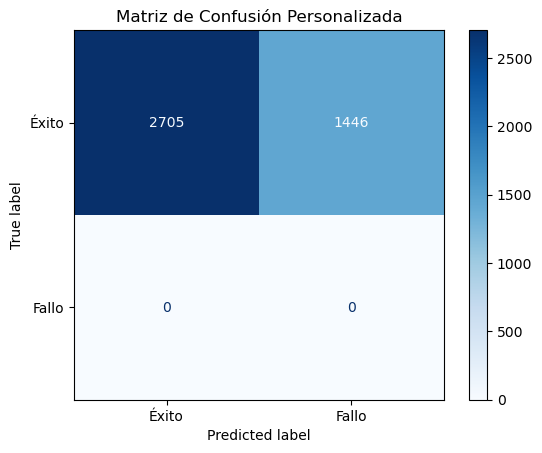


🔎 Iniciando XGBOOST...

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.84      0.91      4151

    accuracy                           0.84      4151
   macro avg       0.50      0.42      0.46      4151
weighted avg       1.00      0.84      0.91      4151



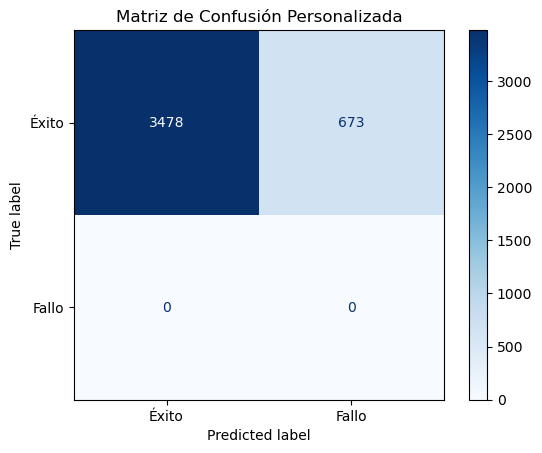


🔎 Iniciando CatBoost...

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.40      0.57      4151

    accuracy                           0.40      4151
   macro avg       0.50      0.20      0.29      4151
weighted avg       1.00      0.40      0.57      4151



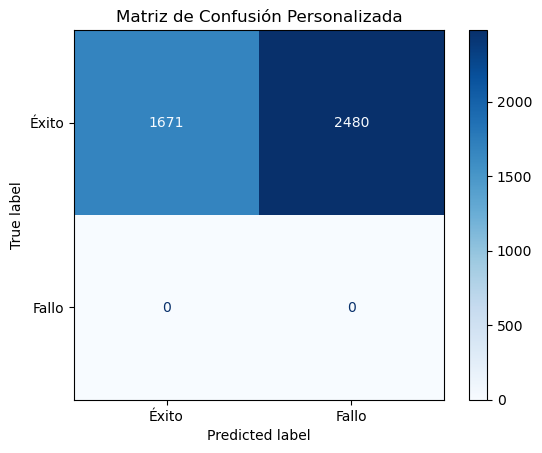

                       test_rmse  test_mae   test_r2  test_recall_margin  \
model_name                                                                 
CatBoostRegressor       1.184461  0.769227  0.308745            0.342960   
RandomForestRegressor   1.212281  0.810278  0.275892            0.332130   
XGBRegressor            1.232034  0.779970  0.252103            0.362214   

                       cv_recall_mean  cv_recall_std  cv_rmse_mean  \
model_name                                                           
CatBoostRegressor            0.343373       0.008466      1.241637   
RandomForestRegressor        0.332831       0.017224      1.247123   
XGBRegressor                 0.362349       0.027550      1.274973   

                       cv_mae_mean  cv_r2_mean  
model_name                                      
CatBoostRegressor         0.796876    0.296614  
RandomForestRegressor     0.820802    0.291310  
XGBRegressor              0.815237    0.255532  


In [40]:

# ------------------------------
# 6) Ejemplo de uso
# ------------------------------



# Supongamos que ya tienes:
df = df_usar_filtrado    # tu DataFrame
feature_cols = col_usar # lista de columnas X
target_col = var_objetivo  # ejemplo

resultados, modelos = comparar_modelos(
    df,
    feature_cols,
    target_col,
    margin=0.3,
    n_splits=5,
    rf_params=None,     # puedes pasar dicts para tunear rápidamente
    xgb_params=None,
    cat_params=None,
    category_columns=cols_to_category
)

print(resultados)

# Accede a un modelo entrenado:
# modelos["XGBoost"].predict(X_new)
